# Phase 1: Data Exploration & Quality Assessment

This section covers the initial exploratory data analysis (EDA) for the Fashion and Beauty supply chain dataset, following the plan in ds_proposal.md.

## 1. Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, and any other libraries needed for data analysis and visualization.

In [61]:
# Import Required Libraries
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
import datetime

# Set visualization style
sns.set(style="whitegrid")

## 2. Load DataSets

In [2]:
# 2. Load Dataset
df = pd.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
df_data_co_supply_chain_pl= pl.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df_data_co_supply_chain_pl.columns

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [4]:
irrelevant_columns = []
for column in df_data_co_supply_chain_pl.columns:
    if df_data_co_supply_chain_pl[column].n_unique() == 1:
       logger.warning(f"\033[94m{column}\033[0m unique value: {df_data_co_supply_chain_pl[column][0]}")
       irrelevant_columns.append(column)

2026-04-16 10:55:10.354 | WARNING  | __main__:<module>:4 - Customer Email unique value: XXXXXXXXX
2026-04-16 10:55:10.359 | WARNING  | __main__:<module>:4 - Customer Password unique value: XXXXXXXXX
2026-04-16 10:55:10.401 | WARNING  | __main__:<module>:4 - Product Description unique value: None
2026-04-16 10:55:10.408 | WARNING  | __main__:<module>:4 - Product Status unique value: 0


In [5]:
df_data_future_data_chain_pl= pl.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/future_data.csv', encoding='latin1')
df_data_future_data_chain_pl.head(5)


Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
str,i64,i64,f64,f64,str,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,str,f64,f64,str,str,str,i64,str,i64,i64,f64,f64,i64,f64,f64,i64,f64,f64,f64,str,str,str,str,i64,i64,str,str,str,f64,i64,str,str
"""PAYMENT""",4,4,14.07,48.5,"""Shipping on time""",0,24,"""Women's Apparel""","""La Habra""","""EE. UU.""","""XXXXXXXXX""","""Beverly""",9100,"""Smith""","""XXXXXXXXX""","""Consumer""","""CA""","""403 Tawny Hills By-pass""",90631.0,5,"""Golf""",33.939163,-117.949554,"""LATAM""","""Salvador""","""Brasil""",9100,"""2015-03-31 00:03:00""",6098,502,1.5,0.03,15234,50.0,0.29,1,50.0,48.5,14.07,"""South America""","""Bahía""","""PENDING_PAYMENT""",null,502,24,null,"""http://images.acmesports.sport…","""Nike Men's Dri-FIT Victory Gol…",50.0,0,"""4/4/2015 0:03""","""Standard Class"""
"""PAYMENT""",4,4,16.6,165.990005,"""Shipping on time""",0,48,"""Water Sports""","""La Habra""","""EE. UU.""","""XXXXXXXXX""","""Beverly""",9100,"""Smith""","""XXXXXXXXX""","""Consumer""","""CA""","""403 Tawny Hills By-pass""",90631.0,7,"""Fan Shop""",33.939163,-117.949554,"""LATAM""","""Salvador""","""Brasil""",9100,"""2015-03-31 00:03:00""",6098,1073,34.0,0.17,15236,199.990005,0.1,1,199.990005,165.990005,16.6,"""South America""","""Bahía""","""PENDING_PAYMENT""",null,1073,48,null,"""http://images.acmesports.sport…","""Pelican Sunstream 100 Kayak""",199.990005,0,"""4/4/2015 0:03""","""Standard Class"""
"""PAYMENT""",4,4,70.519997,163.990005,"""Shipping on time""",0,48,"""Water Sports""","""La Habra""","""EE. UU.""","""XXXXXXXXX""","""Beverly""",9100,"""Smith""","""XXXXXXXXX""","""Consumer""","""CA""","""403 Tawny Hills By-pass""",90631.0,7,"""Fan Shop""",33.939163,-117.949554,"""LATAM""","""Salvador""","""Brasil""",9100,"""2015-03-31 00:03:00""",6098,1073,36.0,0.18,15235,199.990005,0.43,1,199.990005,163.990005,70.519997,"""South America""","""Bahía""","""PENDING_PAYMENT""",null,1073,48,null,"""http://images.acmesports.sport…","""Pelican Sunstream 100 Kayak""",199.990005,0,"""4/4/2015 0:03""","""Standard Class"""
"""PAYMENT""",5,4,53.200001,190.0,"""Late delivery""",1,24,"""Women's Apparel""","""Mount Prospect""","""EE. UU.""","""XXXXXXXXX""","""Karen""",2552,"""Smith""","""XXXXXXXXX""","""Consumer""","""IL""","""2877 Thunder Spring Isle""",60056.0,5,"""Golf""",42.036205,-87.961433,"""LATAM""","""Santo Domingo""","""República Dominicana""",2552,"""2015-03-31 00:24:00""",6099,502,10.0,0.05,15239,50.0,0.28,4,200.0,190.0,53.200001,"""Caribbean""","""Santo Domingo""","""PENDING_PAYMENT""",null,502,24,null,"""http://images.acmesports.sport…","""Nike Men's Dri-FIT Victory Gol…",50.0,0,"""4/5/2015 0:24""","""Standard Class"""
"""PAYMENT""",5,4,78.660004,167.369995,"""Late delivery""",1,17,"""Cleats""","""Mount Prospect""","""EE. UU.""","""XXXXXXXXX""","""Karen""",2552,"""Smith""","""XXXXXXXXX""","""Consumer""","""IL""","""2877 Thunder Spring Isle""",60056.0,4,"""Apparel""",42.036205,-87.961433,"""LATAM""","""Santo Domingo""","""República Dominicana""",2552,"""2015-03-31 00:24:00""",6099,365,12.6,0.07,15237,59.990002,0.47,3,179.970001,167.369995,78.660004,"""Caribbean""","""Santo Domingo""","""PENDING_PAYMENT"

In [6]:
irrelevant_columns_future_data = []
for column in df_data_future_data_chain_pl.columns:
    if df_data_future_data_chain_pl[column].n_unique() == 1:
       logger.warning(f"\033[94m{column}\033[0m unique value: {df_data_future_data_chain_pl[column][0]}")
       irrelevant_columns_future_data.append(column)

2026-04-16 10:55:13.287 | WARNING  | __main__:<module>:4 - Customer Email unique value: XXXXXXXXX
2026-04-16 10:55:13.294 | WARNING  | __main__:<module>:4 - Customer Password unique value: XXXXXXXXX


2026-04-16 10:55:13.337 | WARNING  | __main__:<module>:4 - Product Description unique value: None
2026-04-16 10:55:13.343 | WARNING  | __main__:<module>:4 - Product Status unique value: 0


In [7]:
df_data_future_data_chain_pl["Type"].unique()

Type
str
"""DEBIT"""
"""PAYMENT"""
"""TRANSFER"""
"""CASH"""


In [8]:
df_data_q1_2015_pl= pl.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/Q1_2015.csv', encoding='latin1')
df_data_q1_2015_pl.head(5)

Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
str,i64,i64,f64,f64,str,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,str,f64,f64,str,str,str,i64,str,i64,i64,f64,f64,i64,f64,f64,i64,f64,f64,f64,str,str,str,str,i64,i64,str,str,str,f64,i64,str,str
"""CASH""",2,4,88.790001,239.979996,"""Advance shipping""",0,43,"""Camping & Hiking""","""Hickory""","""EE. UU.""","""XXXXXXXXX""","""Mary""",11599,"""Malone""","""XXXXXXXXX""","""Consumer""","""NC""","""8708 Indian Horse Highway""",28601.0,7,"""Fan Shop""",35.776661,-81.362625,"""LATAM""","""Mexico City""","""México""",11599,"""2015-01-01 00:00:00""",1,957,60.0,0.2,1,299.980011,0.37,1,299.980011,239.979996,88.790001,"""Central America""","""Distrito Federal""","""CLOSED""",null,957,43,null,"""http://images.acmesports.sport…","""Diamondback Women's Serene Cla…",299.980011,0,"""1/3/2015 0:00""","""Standard Class"""
"""PAYMENT""",3,4,91.18,193.990005,"""Advance shipping""",0,48,"""Water Sports""","""Chicago""","""EE. UU.""","""XXXXXXXXX""","""David""",256,"""Rodriguez""","""XXXXXXXXX""","""Consumer""","""IL""","""7605 Tawny Horse Falls""",60625.0,7,"""Fan Shop""",41.832722,-87.980484,"""LATAM""","""Dos Quebradas""","""Colombia""",256,"""2015-01-01 00:21:00""",2,1073,6.0,0.03,2,199.990005,0.47,1,199.990005,193.990005,91.18,"""South America""","""Risaralda""","""PENDING_PAYMENT""",null,1073,48,null,"""http://images.acmesports.sport…","""Pelican Sunstream 100 Kayak""",199.990005,0,"""1/4/2015 0:21""","""Standard Class"""
"""PAYMENT""",3,4,68.25,227.5,"""Advance shipping""",0,24,"""Women's Apparel""","""Chicago""","""EE. UU.""","""XXXXXXXXX""","""David""",256,"""Rodriguez""","""XXXXXXXXX""","""Consumer""","""IL""","""7605 Tawny Horse Falls""",60625.0,5,"""Golf""",41.832722,-87.980484,"""LATAM""","""Dos Quebradas""","""Colombia""",256,"""2015-01-01 00:21:00""",2,502,22.5,0.09,3,50.0,0.3,5,250.0,227.5,68.25,"""South America""","""Risaralda""","""PENDING_PAYMENT""",null,502,24,null,"""http://images.acmesports.sport…","""Nike Men's Dri-FIT Victory Gol…",50.0,0,"""1/4/2015 0:21""","""Standard Class"""
"""PAYMENT""",3,4,36.470001,107.889999,"""Advance shipping""",0,18,"""Men's Footwear""","""Chicago""","""EE. UU.""","""XXXXXXXXX""","""David""",256,"""Rodriguez""","""XXXXXXXXX""","""Consumer""","""IL""","""7605 Tawny Horse Falls""",60625.0,4,"""Apparel""",41.832722,-87.980484,"""LATAM""","""Dos Quebradas""","""Colombia""",256,"""2015-01-01 00:21:00""",2,403,22.1,0.17,4,129.990005,0.34,1,129.990005,107.889999,36.470001,"""South America""","""Risaralda""","""PENDING_PAYMENT""",null,403,18,null,"""http://images.acmesports.sport…","""Nike Men's CJ Elite 2 TD Footb…",129.990005,0,"""1/4/2015 0:21""","""Standard Class"""
"""CASH""",5,4,33.59,159.940002,"""Late delivery""",1,46,"""Indoor/Outdoor Games""","""San Antonio""","""EE. UU.""","""XXXXXXXXX""","""Brian""",8827,"""Wilson""","""XXXXXXXXX""","""Home Office""","""TX""","""8396 High Corners""",78240.0,7,"""Fan Shop""",29.52001,-98.637413,"""LATAM""","""Dos Quebradas""","""Colombia""",8827,"""2015-01-01 01:03:00""",4,1014,39.98,0.2,8,49.98,0.21,4,199.919998,159.940002,33.59,"""South America""","""Risaralda""","""CLOSED""",null,1014,46,null,

In [9]:
irrelevant_columns_q1_2015 = []
for column in df_data_q1_2015_pl.columns:
    if df_data_q1_2015_pl[column].n_unique() == 1:
       logger.warning(f"\033[94m{column}\033[0m unique value: {df_data_q1_2015_pl[column][0]}")
       irrelevant_columns_q1_2015.append(column)

2026-04-16 10:55:17.023 | WARNING  | __main__:<module>:4 - Customer Email unique value: XXXXXXXXX
2026-04-16 10:55:17.025 | WARNING  | __main__:<module>:4 - Customer Password unique value: XXXXXXXXX
2026-04-16 10:55:17.027 | WARNING  | __main__:<module>:4 - Market unique value: LATAM
2026-04-16 10:55:17.031 | WARNING  | __main__:<module>:4 - Order Zipcode unique value: None
2026-04-16 10:55:17.032 | WARNING  | __main__:<module>:4 - Product Description unique value: None
2026-04-16 10:55:17.034 | WARNING  | __main__:<module>:4 - Product Status unique value: 0


In [10]:
irrelevant_columns_q1_2015 = []
for column in df_data_q1_2015_pl.columns:
    if df_data_q1_2015_pl[column].n_unique() == 1:
       logger.warning(f"\033[94m{column}\033[0m unique value: {df_data_q1_2015_pl[column][0]}")
       irrelevant_columns_q1_2015.append(column)

2026-04-16 10:55:17.805 | WARNING  | __main__:<module>:4 - Customer Email unique value: XXXXXXXXX
2026-04-16 10:55:17.806 | WARNING  | __main__:<module>:4 - Customer Password unique value: XXXXXXXXX
2026-04-16 10:55:17.808 | WARNING  | __main__:<module>:4 - Market unique value: LATAM
2026-04-16 10:55:17.812 | WARNING  | __main__:<module>:4 - Order Zipcode unique value: None
2026-04-16 10:55:17.813 | WARNING  | __main__:<module>:4 - Product Description unique value: None
2026-04-16 10:55:17.814 | WARNING  | __main__:<module>:4 - Product Status unique value: 0


In [11]:
df_data_future_data_chain_pl.shape

(165286, 53)

In [12]:
df_data_co_supply_chain_pl.shape

(180519, 53)

In [13]:
df_data_future_data_chain_pl.columns

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [14]:
df_data_future_data_chain_pl['Market'].unique()


Market
str
"""Europe"""
"""Africa"""
"""Pacific Asia"""
"""USCA"""
"""LATAM"""


In [15]:
df_data_q1_2015_pl.shape

(15233, 53)

In [16]:
len(df_data_future_data_chain_pl.filter(pl.col("Market") == "LATAM"))

36361

In [17]:
df_desciption_pl= pl.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/DescriptionDataCoSupplyChain.csv', encoding='latin1')
for row in df_desciption_pl.iter_rows(named=True):
    print(f"\033[94m{row['FIELDS']}\033[0m", row['DESCRIPTION'])

Type :  Type of transaction made
Days for shipping (real)      :  Actual shipping days of the purchased product
Days for shipment (scheduled) :  Days of scheduled delivery of the purchased product
Benefit per order :  Earnings per order placed
Sales per customer :  Total sales per customer made per customer
Delivery Status :  Delivery status of orders: Advance shipping , Late delivery , Shipping canceled , Shipping on time
Late_delivery_risk            :  Categorical variable that indicates if sending is late (1), it is not late (0).
Category Id :  Product category code
Category Name :  Description of the product category
Customer City :  City where the customer made the purchase
Customer Country :  Country where the customer made the purchase
Customer Email :  Customer's email
Customer Fname :  Customer name
Customer Id :  Customer ID
Customer Lname :  Customer lastname
Customer Password :  Masked customer key
Customer Segment :  Types of Customers: Consumer , Corporate , Home Office


In [67]:
def get_weekday(date_str):
    if pd.isnull(date_str):
        return None
    dt = datetime.datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
    return dt.strftime("%A")


def extract_month(x):
    if pd.isnull(x):
        return None
    if "-" in x:    
        parts = str(x).strip().split("-")
    elif "/" in x:
        parts = str(x).strip().split("/")
    else:
        logger.warning(f"Unexpected date format: {x}")
        parts = []
    if len(parts) > 1:
        return str(parts[0])
    return None


def extract_year(x):
    if pd.isnull(x):
        return None
    if "-" in x:   
        parts = str(x).strip().split()[0].split("-")
    elif "/" in x:
        parts = str(x).strip().split()[0].split("/")
    else:
        parts = []
    if len(parts) > 1:
        return str(parts[2])
    return None


df_cleaned=df[[x for x in df.columns if x not in irrelevant_columns ]]

df_cleaned['month'] = df_cleaned['shipping date (DateOrders)'].apply(extract_month)


df_cleaned['year'] = df_cleaned['shipping date (DateOrders)'].apply(extract_year)

# Extrae el día de la semana en inglés
df_cleaned['weekday'] = pd.to_datetime(df_cleaned['shipping date (DateOrders)'], errors='coerce').dt.day_name()

df_cleaned.to_csv("/home/marc/project/supply_chain_DS/dataco_supply_chain/data/processed/DataCoSupplyChainDataset_cleaned.csv")

In [64]:
def month_to_cyclic(month):
    return np.cos(2 * np.pi * (month - 1) / 12)

def weekday_to_cyclic(weekday):
    """
    Convierte el día de la semana (0=lunes, 6=domingo) a valor cíclico [-1, 1]
    """
    return np.cos(2 * np.pi * weekday / 7)

def dayhour_to_cyclic(hour):
    """
    Convierte la hora del día (0-23) a valor cíclico [-1, 1]
    """
    return np.cos(2 * np.pi * hour / 24)

In [65]:
irrelevant_columns

['Customer Email',
 'Customer Password',
 'Product Description',
 'Product Status']

In [66]:

sorted(df_cleaned['month'].unique())


['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9']

In [23]:
df_cleaned['shipping date (DateOrders)']

0          2/3/2018 22:56
1         1/18/2018 12:27
2         1/17/2018 12:06
3         1/16/2018 11:45
4         1/15/2018 11:24
               ...       
180514     1/20/2016 3:40
180515     1/19/2016 1:34
180516    1/20/2016 21:00
180517    1/18/2016 20:18
180518    1/19/2016 18:54
Name: shipping date (DateOrders), Length: 180519, dtype: str

In [60]:
def mes_a_ciclico(mes):
    return np.cos(2 * np.pi * (mes - 1) / 12)

# Ejemplo:
for mes in range(1, 13):
    print(f"Mes {mes}: {mes_a_ciclico(mes):.2f}")

Mes 1: 1.00
Mes 2: 0.87
Mes 3: 0.50
Mes 4: 0.00
Mes 5: -0.50
Mes 6: -0.87
Mes 7: -1.00
Mes 8: -0.87
Mes 9: -0.50
Mes 10: -0.00
Mes 11: 0.50
Mes 12: 0.87


## 3. Inspect Data Types and Missing Values in summary table
Display the data types, count missing values per column, and show the number of unique values for each column.

In [ ]:
len(df_cleaned)


180519

In [75]:
# Table: Column, Type, Non-Null Values, Unique Values, Sample Values
summary_table = pd.DataFrame({
    'Column': df_cleaned.columns,
    'Type': [df_cleaned[col].dtype for col in df_cleaned.columns],
    'Non-Null Count': [df_cleaned[col].notnull().sum() for col in df_cleaned.columns],
    'Unique Values': [df_cleaned[col].nunique() for col in df_cleaned.columns],
    'Values': [df_cleaned[col].unique() if df_cleaned[col].nunique() < 13 else 'Too many unique values' for col in df_cleaned.columns]
})
display(summary_table)

,Column,Type,Non-Null Count,Unique Values,Values
0,Type,str,180519,4,"[DEBIT, TRANSFER, CASH, PAYMENT]"
1,Days for shipping (real),int64,180519,7,"[3, 5, 4, 2, 6, 0, 1]"
2,Days for shipment (scheduled),int64,180519,4,"[4, 1, 2, 0]"
3,Benefit per order,float64,180519,21998,Too many unique values
4,Sales per customer,float64,180519,2927,Too many unique values
5,Delivery Status,str,180519,4,"[Advance shipping, Late delivery, Shipping on ..."
6,Late_delivery_risk,int64,180519,2,"[0, 1]"
7,Category Id,int64,180519,51,Too many unique values
8,Category Name,str,180519,50,Too many unique values
9,Customer City,str,180519,563,Too many unique values


118 diferent product grouped in 51 categories. Columns of products can be unified to one () 
In the dataset, there is only 2 countries from customers:[Puerto Rico, EE. UU.]

## 4. Analyze Numerical Feature Distributions
Visualize and describe distributions for numerical features such as Price, Number of products sold, Revenue, Stock levels, Lead times, and Costs.

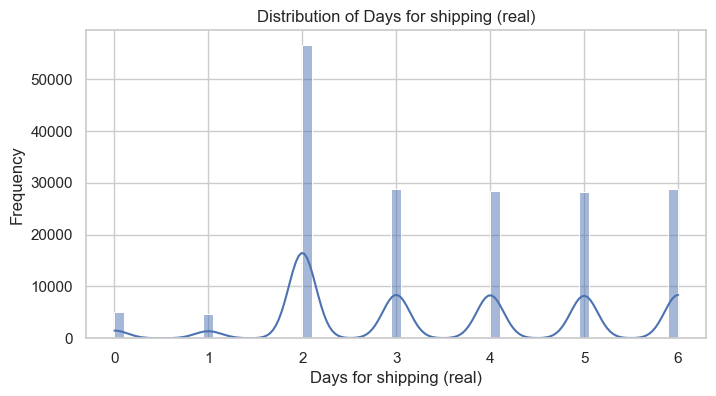

count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64


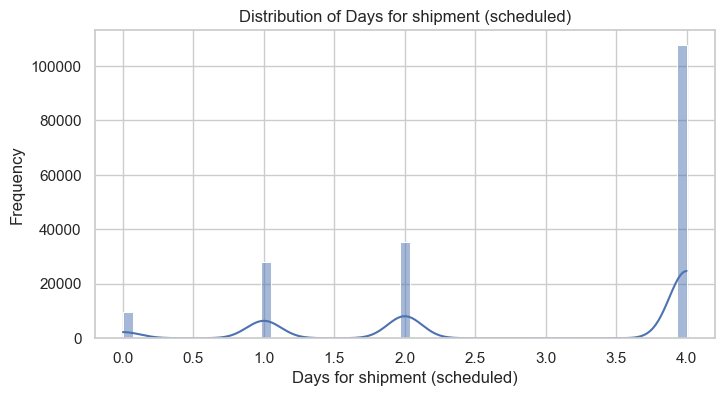

count    180519.000000
mean          2.931847
std           1.374449
min           0.000000
25%           2.000000
50%           4.000000
75%           4.000000
max           4.000000
Name: Days for shipment (scheduled), dtype: float64


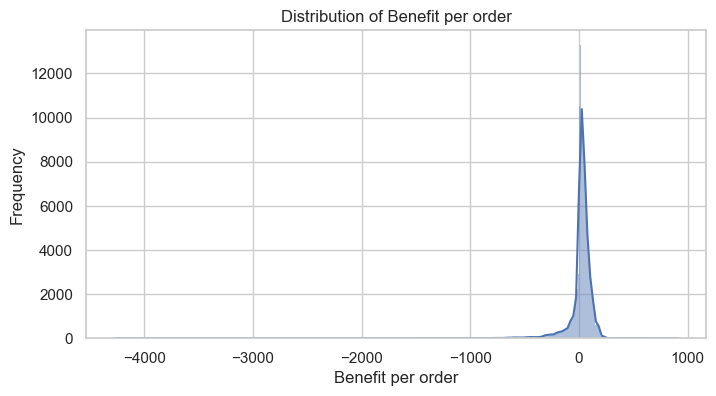

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Benefit per order, dtype: float64


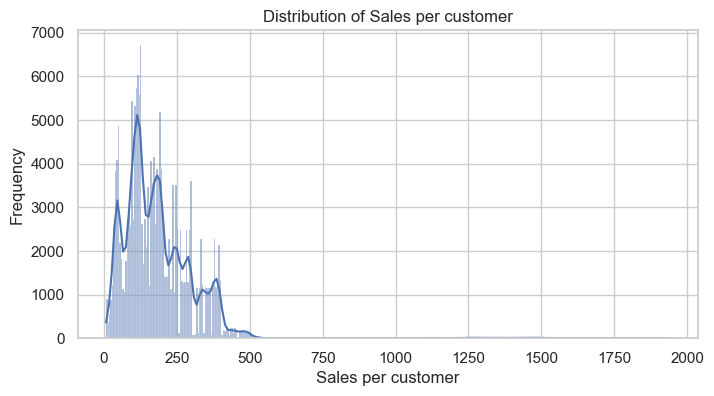

count    180519.000000
mean        183.107609
std         120.043670
min           7.490000
25%         104.379997
50%         163.990005
75%         247.399994
max        1939.989990
Name: Sales per customer, dtype: float64


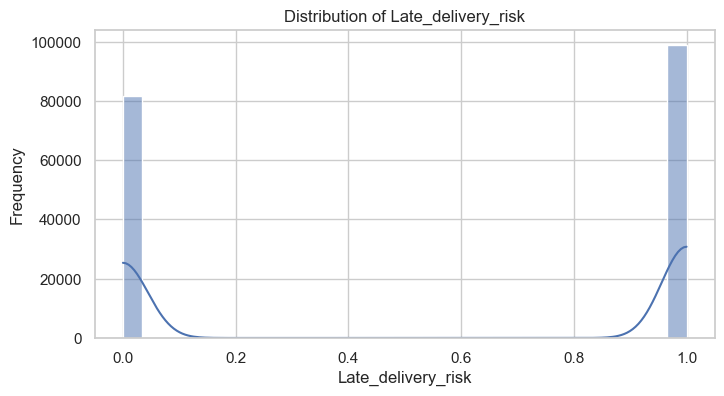

count    180519.000000
mean          0.548291
std           0.497664
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Late_delivery_risk, dtype: float64


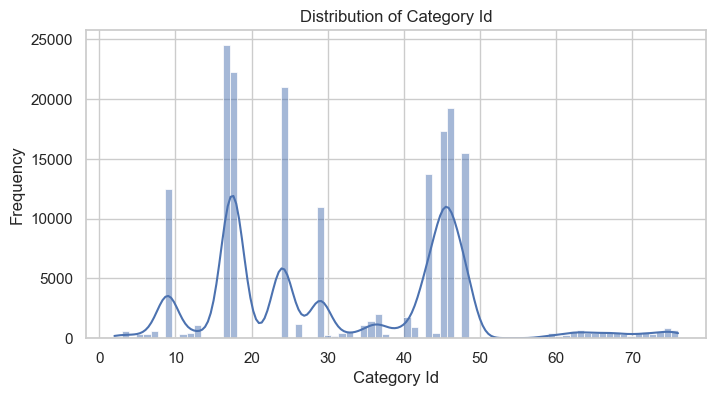

count    180519.000000
mean         31.851451
std          15.640064
min           2.000000
25%          18.000000
50%          29.000000
75%          45.000000
max          76.000000
Name: Category Id, dtype: float64


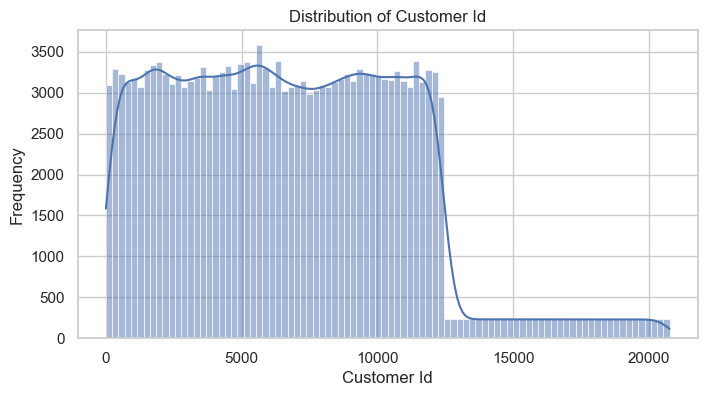

count    180519.000000
mean       6691.379495
std        4162.918106
min           1.000000
25%        3258.500000
50%        6457.000000
75%        9779.000000
max       20757.000000
Name: Customer Id, dtype: float64


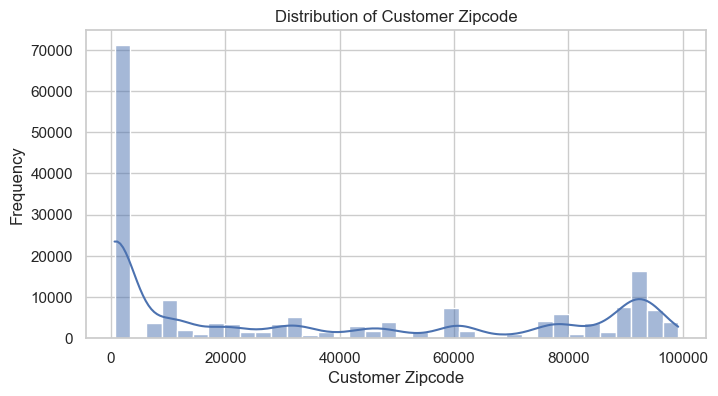

count    180516.000000
mean      35921.126914
std       37542.461122
min         603.000000
25%         725.000000
50%       19380.000000
75%       78207.000000
max       99205.000000
Name: Customer Zipcode, dtype: float64


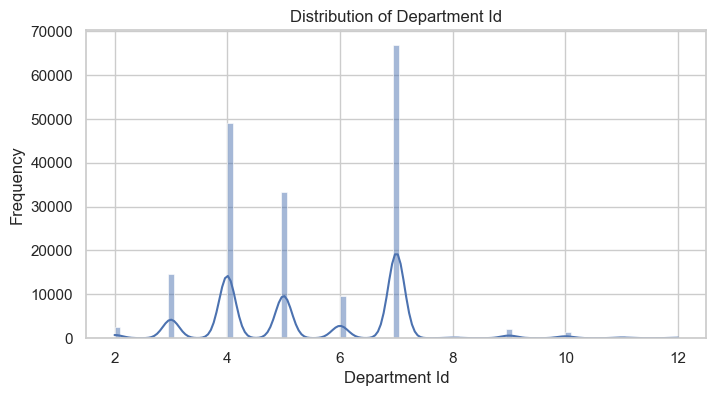

count    180519.000000
mean          5.443460
std           1.629246
min           2.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          12.000000
Name: Department Id, dtype: float64


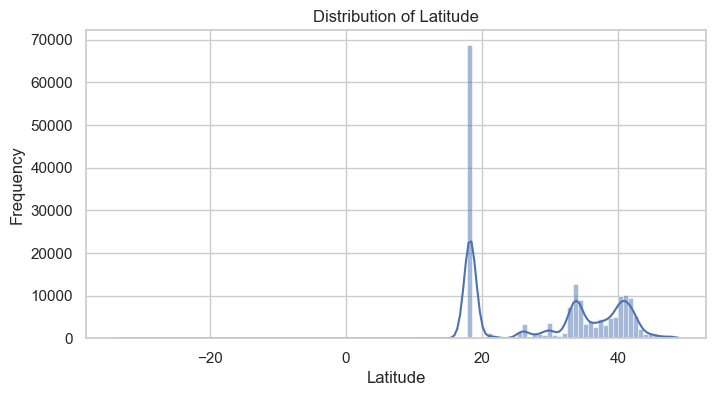

count    180519.000000
mean         29.719955
std           9.813646
min         -33.937553
25%          18.265432
50%          33.144863
75%          39.279617
max          48.781933
Name: Latitude, dtype: float64


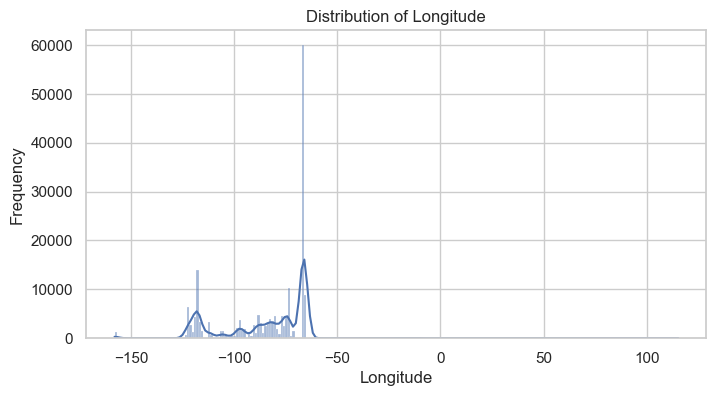

count    180519.000000
mean        -84.915675
std          21.433241
min        -158.025986
25%         -98.446312
50%         -76.847908
75%         -66.370583
max         115.263077
Name: Longitude, dtype: float64


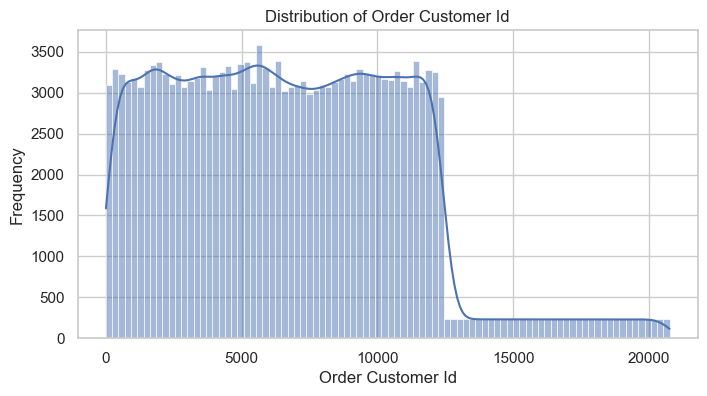

count    180519.000000
mean       6691.379495
std        4162.918106
min           1.000000
25%        3258.500000
50%        6457.000000
75%        9779.000000
max       20757.000000
Name: Order Customer Id, dtype: float64


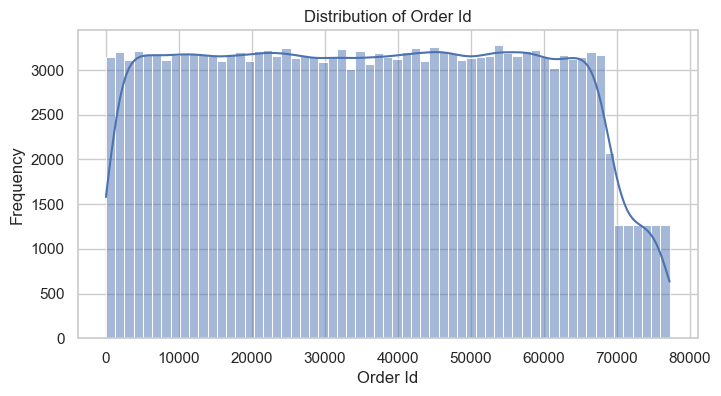

count    180519.000000
mean      36221.894903
std       21045.379569
min           1.000000
25%       18057.000000
50%       36140.000000
75%       54144.000000
max       77204.000000
Name: Order Id, dtype: float64


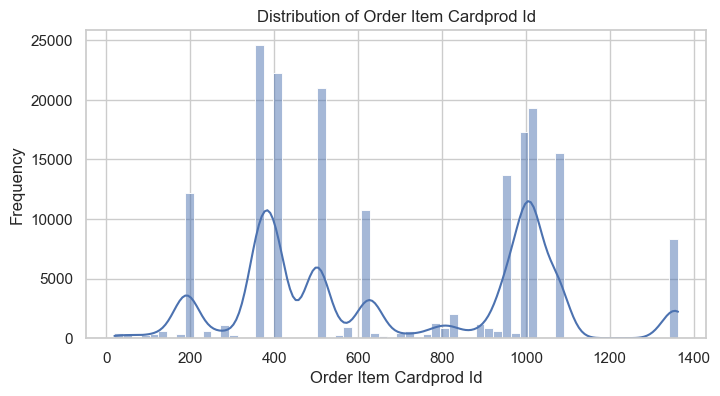

count    180519.000000
mean        692.509764
std         336.446807
min          19.000000
25%         403.000000
50%         627.000000
75%        1004.000000
max        1363.000000
Name: Order Item Cardprod Id, dtype: float64


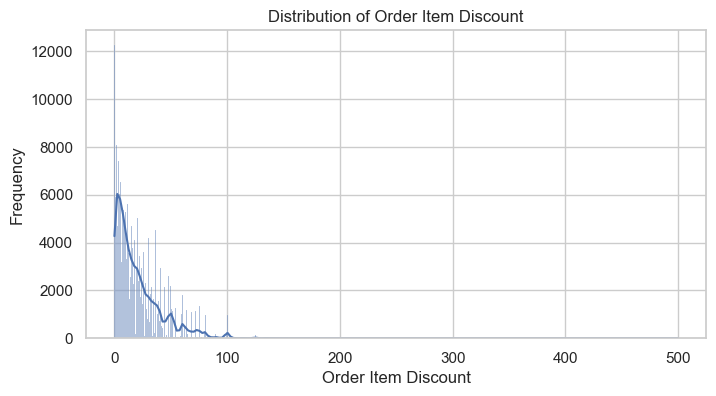

count    180519.000000
mean         20.664741
std          21.800901
min           0.000000
25%           5.400000
50%          14.000000
75%          29.990000
max         500.000000
Name: Order Item Discount, dtype: float64


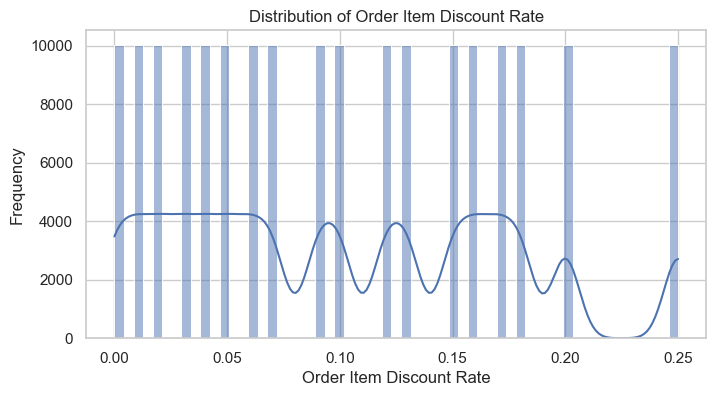

count    180519.000000
mean          0.101668
std           0.070415
min           0.000000
25%           0.040000
50%           0.100000
75%           0.160000
max           0.250000
Name: Order Item Discount Rate, dtype: float64


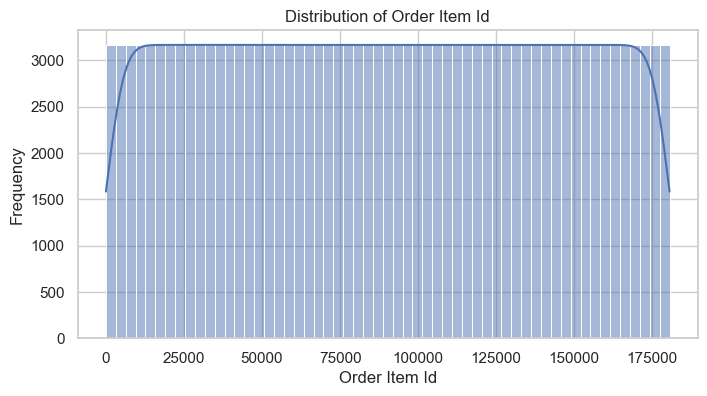

count    180519.000000
mean      90260.000000
std       52111.490959
min           1.000000
25%       45130.500000
50%       90260.000000
75%      135389.500000
max      180519.000000
Name: Order Item Id, dtype: float64


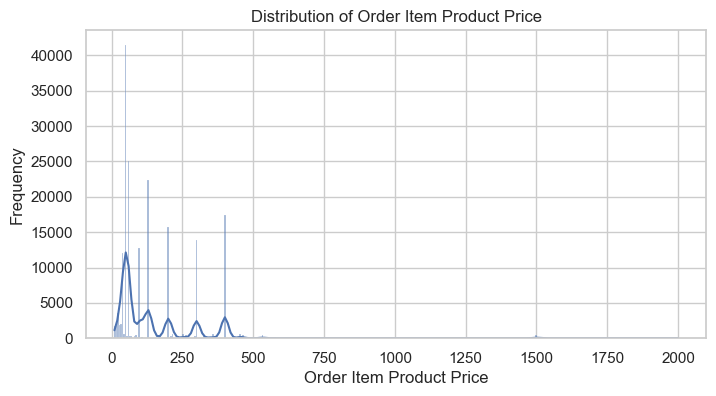

count    180519.000000
mean        141.232550
std         139.732492
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max        1999.989990
Name: Order Item Product Price, dtype: float64


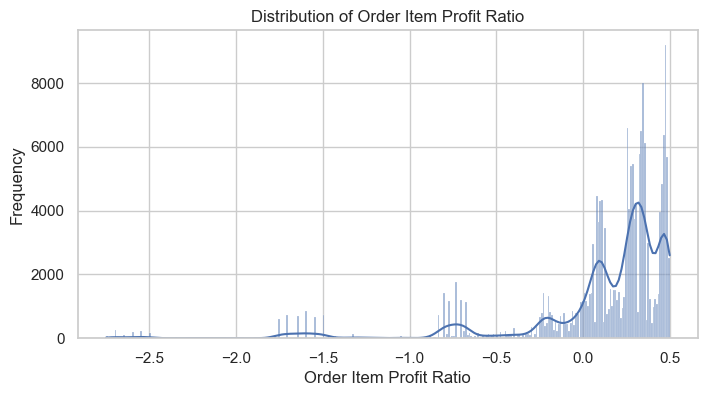

count    180519.000000
mean          0.120647
std           0.466796
min          -2.750000
25%           0.080000
50%           0.270000
75%           0.360000
max           0.500000
Name: Order Item Profit Ratio, dtype: float64


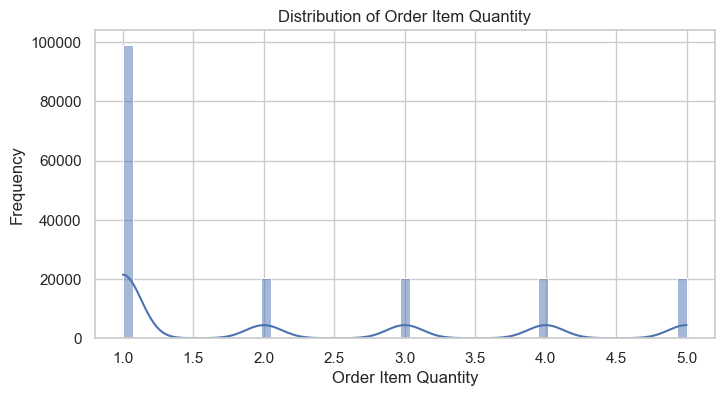

count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: Order Item Quantity, dtype: float64


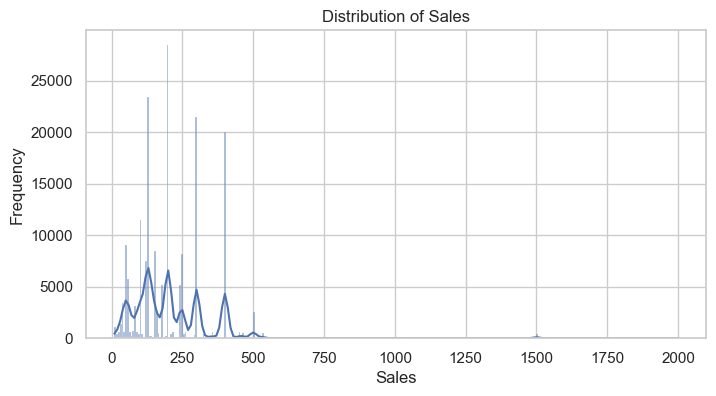

count    180519.000000
mean        203.772096
std         132.273077
min           9.990000
25%         119.980003
50%         199.919998
75%         299.950012
max        1999.989990
Name: Sales, dtype: float64


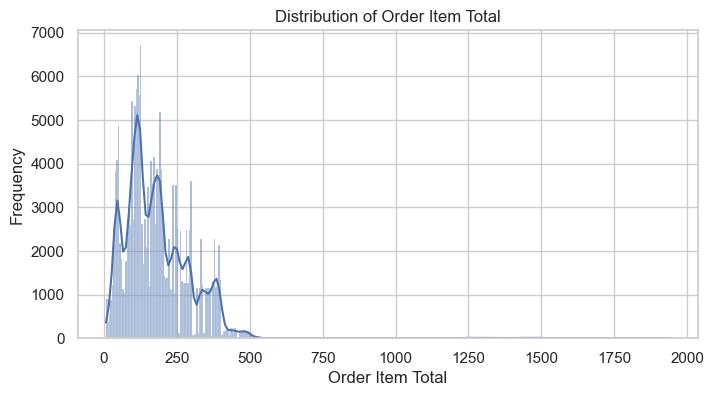

count    180519.000000
mean        183.107609
std         120.043670
min           7.490000
25%         104.379997
50%         163.990005
75%         247.399994
max        1939.989990
Name: Order Item Total, dtype: float64


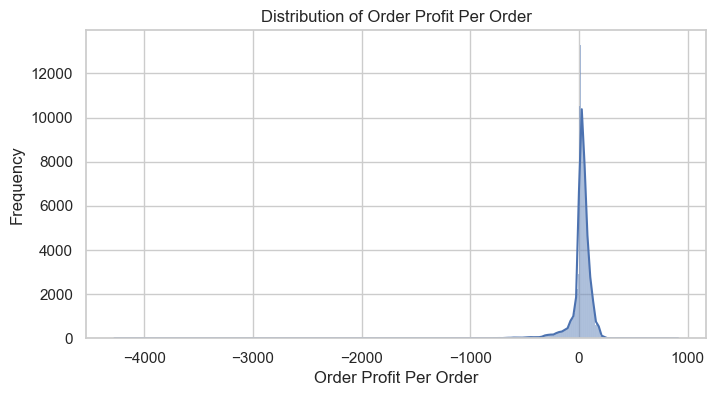

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Order Profit Per Order, dtype: float64


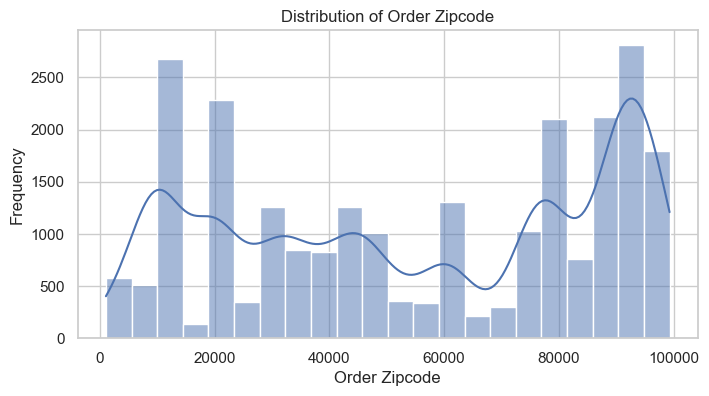

count    24840.000000
mean     55426.132327
std      31919.279101
min       1040.000000
25%      23464.000000
50%      59405.000000
75%      90008.000000
max      99301.000000
Name: Order Zipcode, dtype: float64


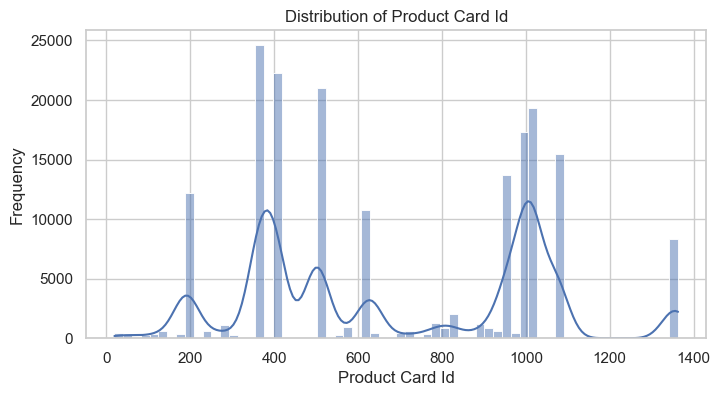

count    180519.000000
mean        692.509764
std         336.446807
min          19.000000
25%         403.000000
50%         627.000000
75%        1004.000000
max        1363.000000
Name: Product Card Id, dtype: float64


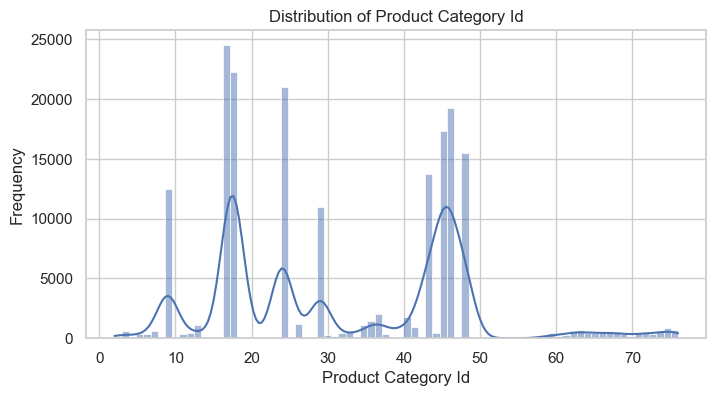

count    180519.000000
mean         31.851451
std          15.640064
min           2.000000
25%          18.000000
50%          29.000000
75%          45.000000
max          76.000000
Name: Product Category Id, dtype: float64


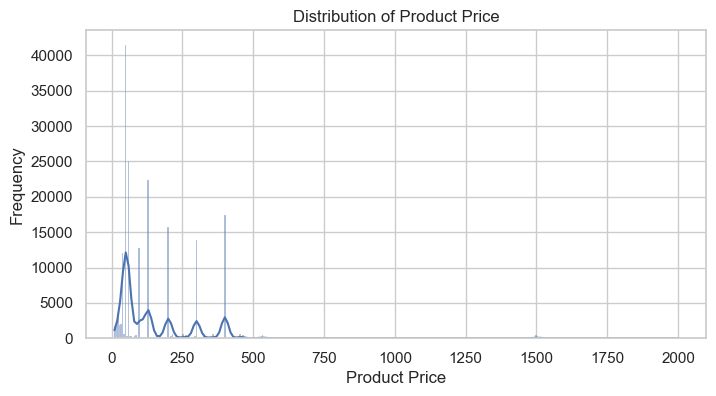

count    180519.000000
mean        141.232550
std         139.732492
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max        1999.989990
Name: Product Price, dtype: float64


In [78]:
# 4. Analyze Numerical Feature Distributions
numerical_cols = [x for x in df_cleaned.columns if df_cleaned[x].dtype in ['int64', 'float64']]
for col in numerical_cols:
    if col in df_cleaned.columns and df_cleaned[col].nunique() > 1:
        plt.figure(figsize=(8, 4))
        sns.histplot(df_cleaned[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
        print(df_cleaned[col].describe())

## 5. Explore Categorical Feature Distributions
Visualize and summarize the distributions of categorical features like Product Type, SKU, Supplier name, Location, Shipping carriers, and Transportation modes.

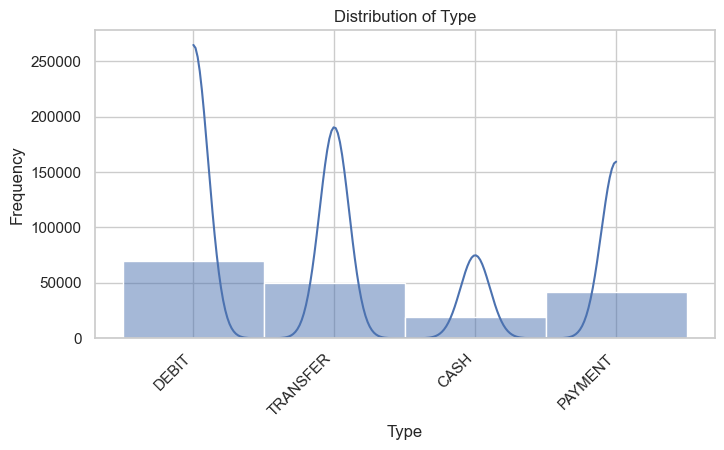

count     180519
unique         4
top        DEBIT
freq       69295
Name: Type, dtype: object


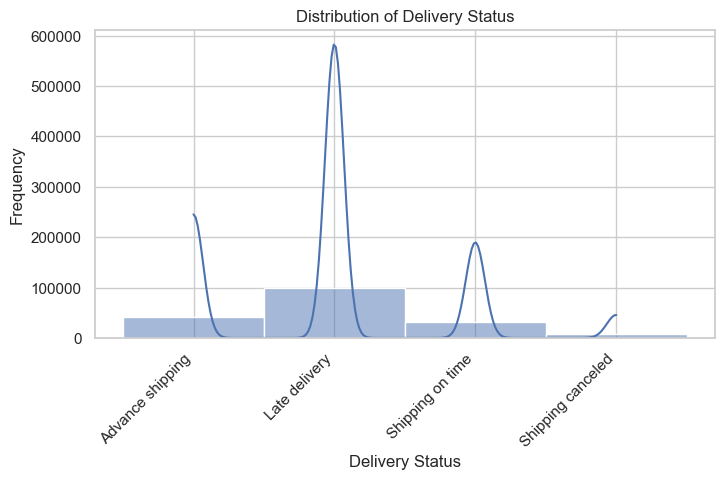

count            180519
unique                4
top       Late delivery
freq              98977
Name: Delivery Status, dtype: object


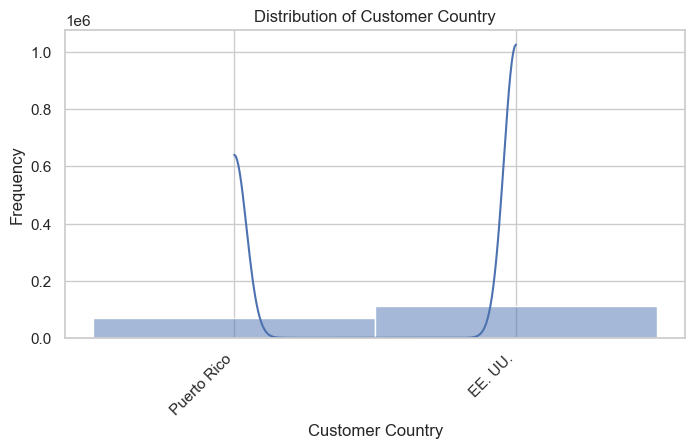

count      180519
unique          2
top       EE. UU.
freq       111146
Name: Customer Country, dtype: object


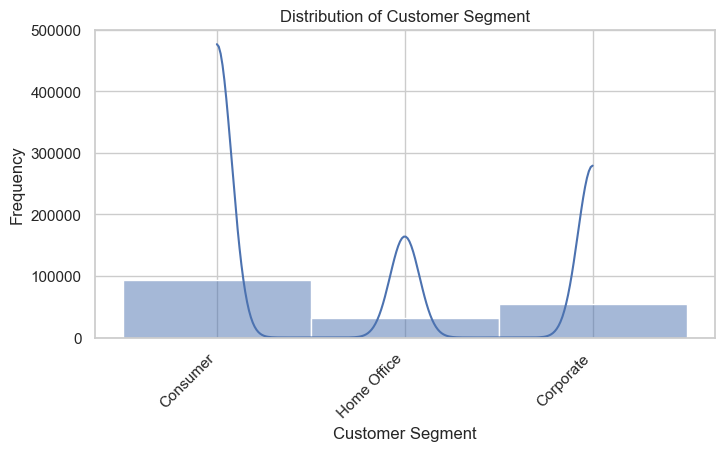

count       180519
unique           3
top       Consumer
freq         93504
Name: Customer Segment, dtype: object


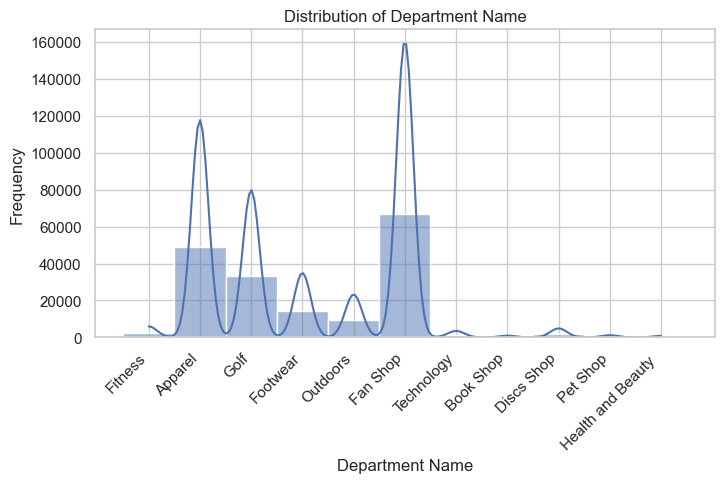

count       180519
unique          11
top       Fan Shop
freq         66861
Name: Department Name, dtype: object


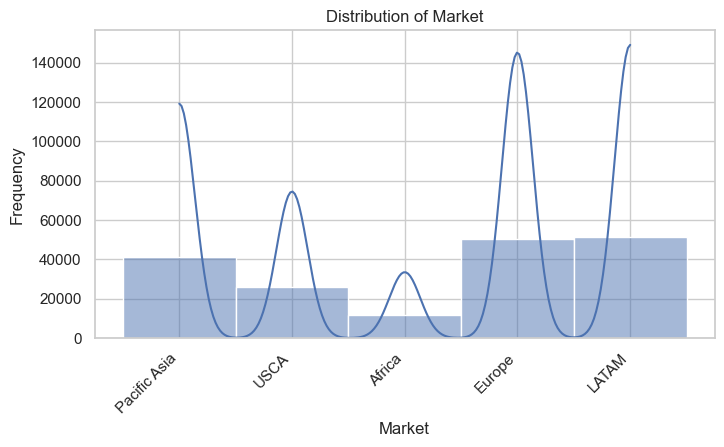

count     180519
unique         5
top        LATAM
freq       51594
Name: Market, dtype: object


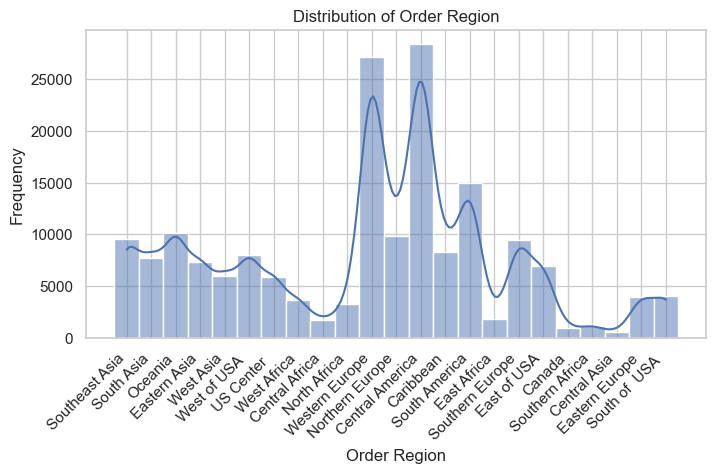

count              180519
unique                 23
top       Central America
freq                28341
Name: Order Region, dtype: object


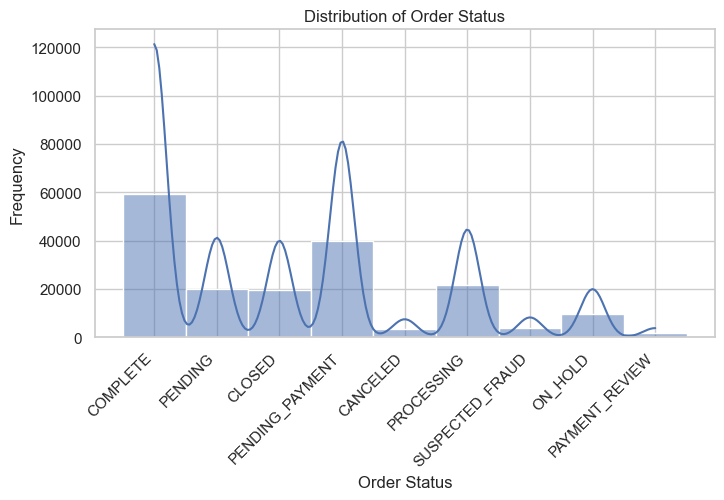

count       180519
unique           9
top       COMPLETE
freq         59491
Name: Order Status, dtype: object


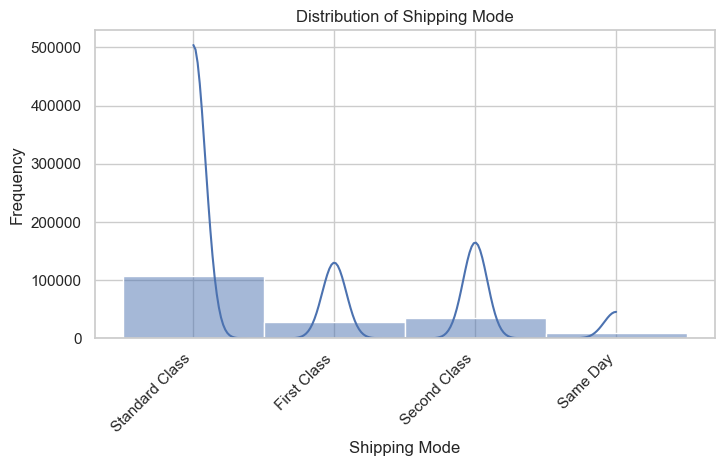

count             180519
unique                 4
top       Standard Class
freq              107752
Name: Shipping Mode, dtype: object


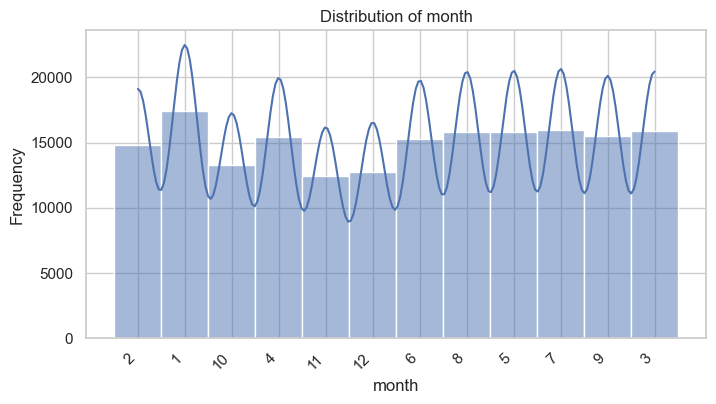

count     180519
unique        12
top            1
freq       17404
Name: month, dtype: object


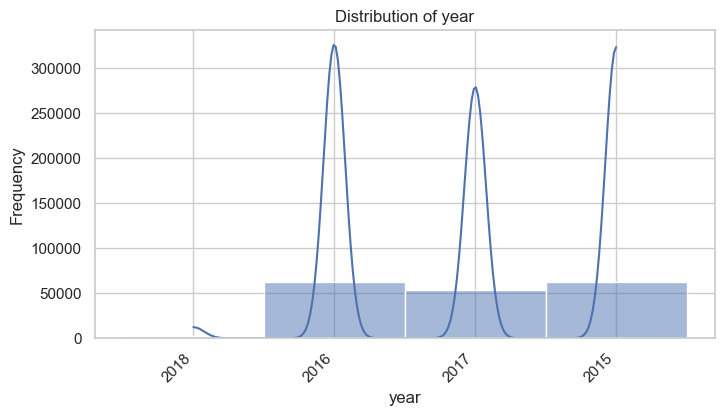

count     180519
unique         4
top         2016
freq       62602
Name: year, dtype: object


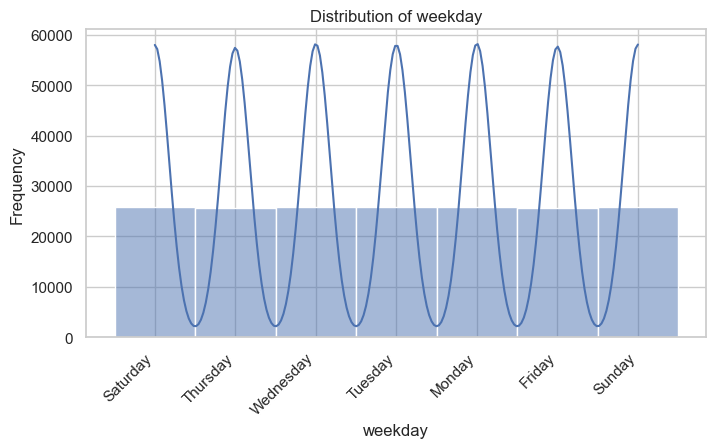

count     180519
unique         7
top       Monday
freq       25923
Name: weekday, dtype: object


In [82]:
categorical_cols = [x for x in df_cleaned.columns if df_cleaned[x].dtype in ['str']]
for col in categorical_cols:
    if col in df_cleaned.columns and df_cleaned[col].nunique() < 30:
        plt.figure(figsize=(8, 4))
        sns.histplot(df_cleaned[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Frequency')
        plt.show()
        print(df_cleaned[col].describe())

## 6. Identify Outliers and Anomalies
Detect and visualize outliers or anomalies in key columns (e.g., negative sales, extreme costs, implausible lead times) using boxplots or other methods.

In [87]:
numerical_cols_relevant=[ 'Benefit per order',
 'Sales per customer',
 'Latitude',
 'Longitude',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Product Price']

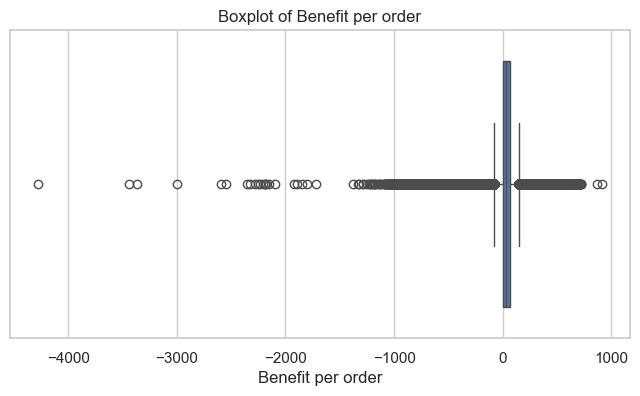

Negative values in Benefit per order: 33784


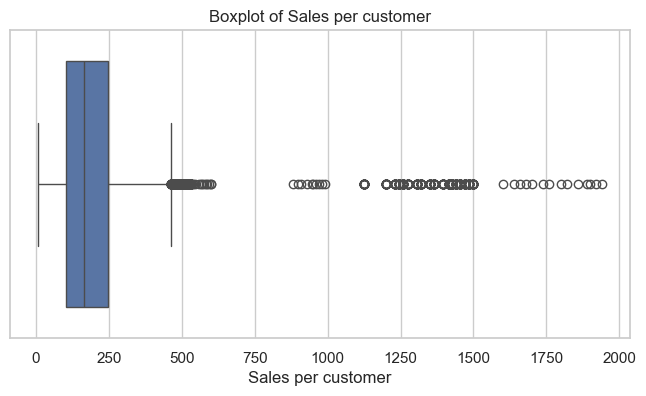

Negative values in Sales per customer: 0


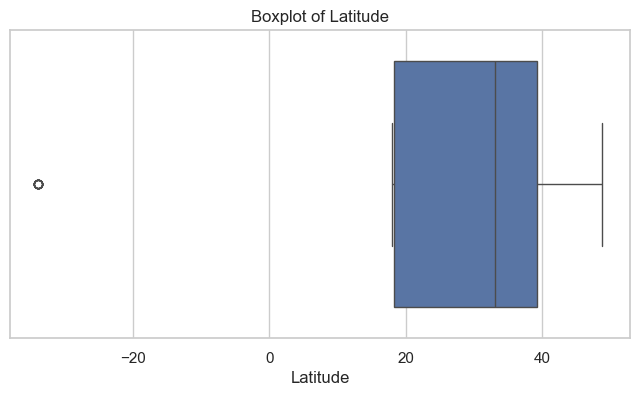

Negative values in Latitude: 9


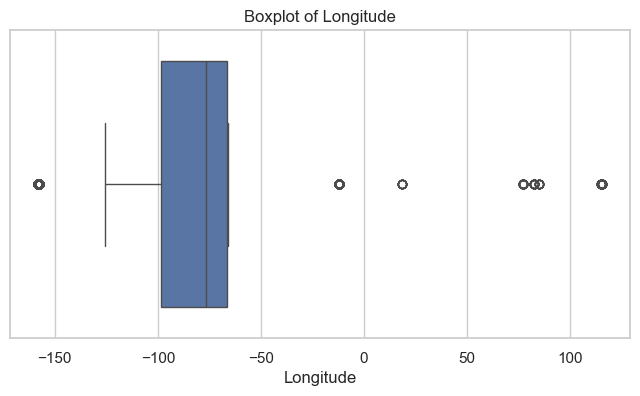

Negative values in Longitude: 180414


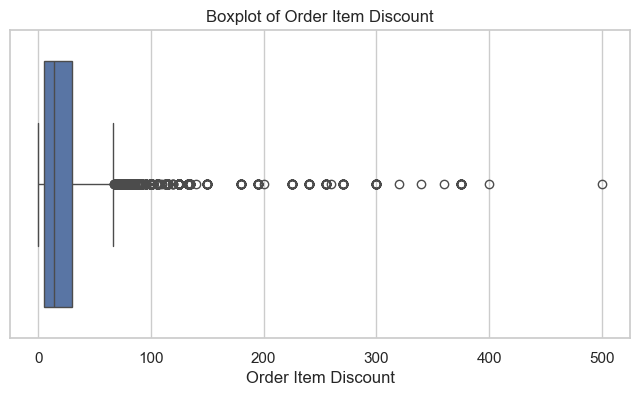

Negative values in Order Item Discount: 0


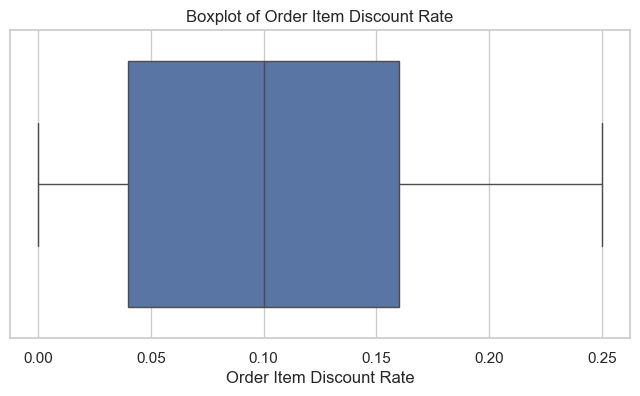

Negative values in Order Item Discount Rate: 0


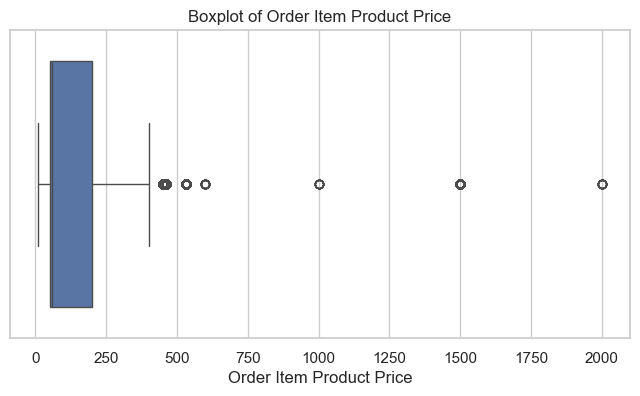

Negative values in Order Item Product Price: 0


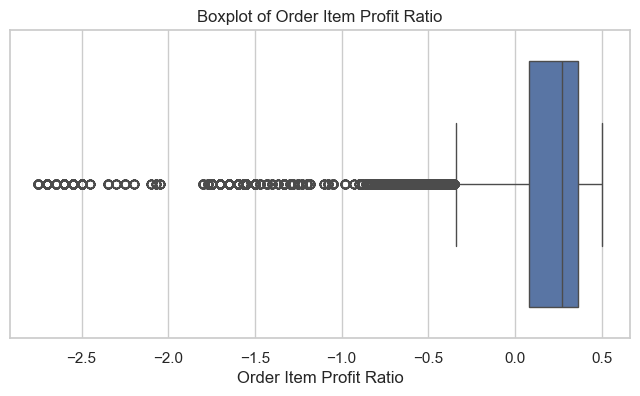

Negative values in Order Item Profit Ratio: 33784


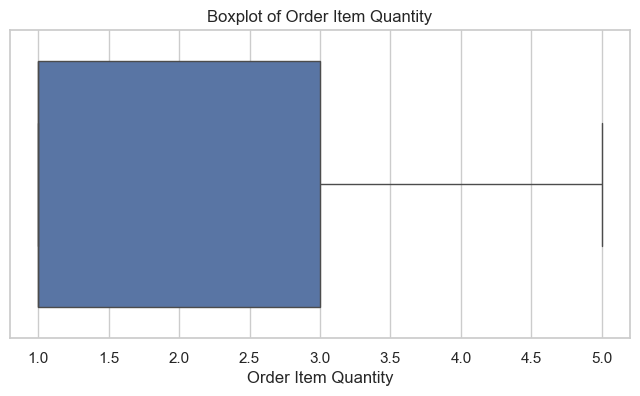

Negative values in Order Item Quantity: 0


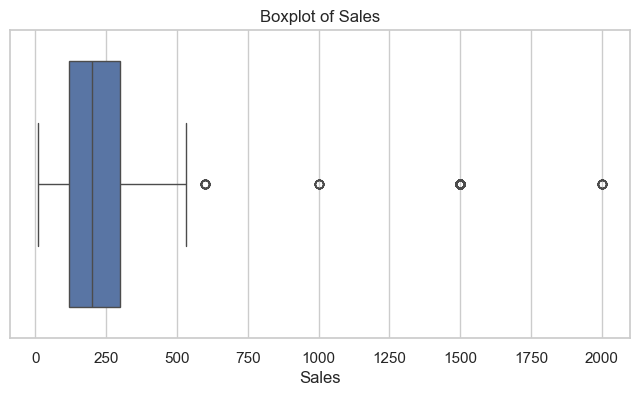

Negative values in Sales: 0


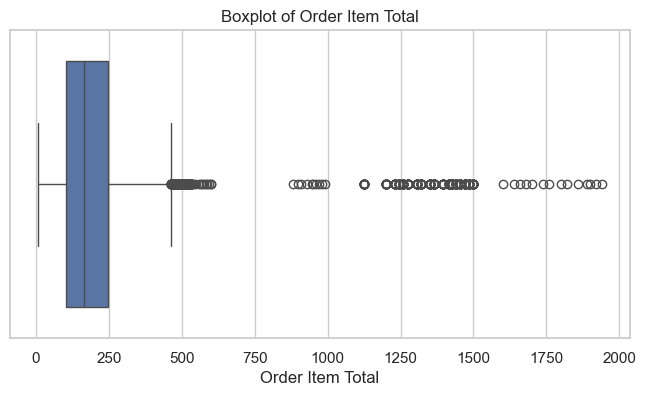

Negative values in Order Item Total: 0


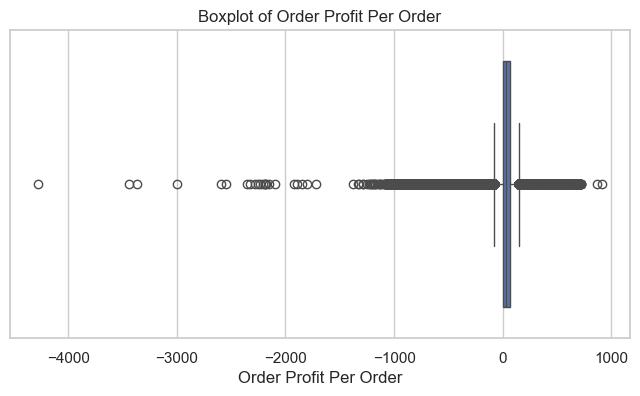

Negative values in Order Profit Per Order: 33784


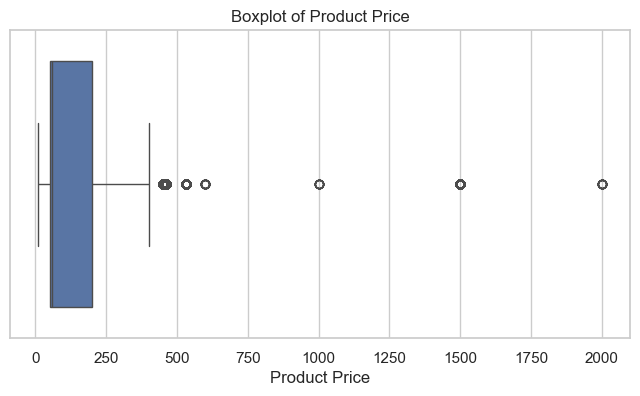

Negative values in Product Price: 0


In [88]:
# 6. Identify Outliers and Anomalies
# Example: Boxplots for key numerical columns
for col in numerical_cols_relevant:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col].dropna())
        plt.title(f'Boxplot of {col}')
        plt.show()
        # Check for negative or implausible values
        print(f"Negative values in {col}:", (df[col] < 0).sum())

## 7. Summarize Data Quality Issues
Document findings on missingness, duplicates, and inconsistencies in the dataset.

---

This concludes Phase 1: Data Exploration & Quality Assessment. The next phase will focus on feature relevance for demand forecasting and safety stock.

In [ ]:
def get_weekday(date_str):
    dt = datetime.datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
    return dt.strftime("%A")

get_weekday("2015-03-31 00:03:00")

month=(data).strip().split("-")[1]

'Tuesday'